In [2]:
!nvidia-smi

!pip -q install ultralytics==8.3.* \
scikit-learn \
imagecorruptions \
pycocotools \
opencv-python-headless

Sun Sep 20 13:54:24 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
!ps aux | grep pip

root        4355  0.0  0.0   7344  3644 ?        S    13:54   0:00 /bin/bash -c ps aux | grep pip
root        4357  0.0  0.0   6548  2364 ?        S    13:54   0:00 grep pip


In [4]:
%cd /content

!mkdir -p self-healing-detector
%cd self-healing-detector

!mkdir -p \
configs \
scripts \
src/data src/model src/monitor src/adapt src/eval src/enhance \
results/logs results/tables results/figures \
weights runs \
data/raw/bdd100k/images \
data/raw/bdd100k/labels \
data/yolo \
data/manifests

/content
/content/self-healing-detector


In [5]:
!pip -q install kaggle

In [7]:
import os
import getpass

os.environ["KAGGLE_USERNAME"] = input("Kaggle Username:")
os.environ["KAGGLE_KEY"] = getpass.getpass("Kaggle API Key: ")

Kaggle Username:vardhanvelamakanni
Kaggle API Key: ··········


In [8]:
!kaggle datasets list -s bdd100k | head

ref                                                       title                                                  size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------  ----------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
solesensei/solesensei_bdd100k                             bdd100k                                          8166127525  2019-05-21 21:10:21.507000          45543        157  0.75             
marquis03/bdd100k                                         BDD100K Images                                   5781166420  2023-12-15 14:12:18.997000           3673         20  1                
marquis03/bdd100k-weather-classification                  BDD100K Weather Classification                   5662942691  2023-12-15 14:28:34.747000           1239         24  1                
a7madmostafa/bdd100k-yolo                    

In [17]:
# Remove everything downloaded so far
!rm -rf /content/self-healing-detector/data/raw/*

# Recreate the raw folder
!mkdir -p /content/self-healing-detector/data/raw

# Verify it's empty
!ls -la /content/self-healing-detector/data/raw

total 8
drwxr-xr-x 2 root root 4096 Sep 20 14:24 .
drwxr-xr-x 5 root root 4096 Sep 20 13:55 ..


In [24]:
!rm -rf /content/self-healing-detector/data/raw/*
!mkdir -p /content/self-healing-detector/data/raw

In [25]:
%cd /content/self-healing-detector/data/raw

!kaggle datasets download -d soumikrakshit/bdd100k -p .

/content/self-healing-detector/data/raw
Dataset URL: https://www.kaggle.com/datasets/soumikrakshit/bdd100k
License(s): unknown
100% 6.37G/6.37G [00:39<00:00, 175MB/s]



In [26]:
!unzip -q bdd100k.zip
!rm bdd100k.zip

In [27]:
!find /content/self-healing-detector/data/raw -maxdepth 5 | sort

/content/self-healing-detector/data/raw
/content/self-healing-detector/data/raw/bdd100k_det_20_labels_trainval
/content/self-healing-detector/data/raw/bdd100k_det_20_labels_trainval/bdd100k
/content/self-healing-detector/data/raw/bdd100k_det_20_labels_trainval/bdd100k/labels
/content/self-healing-detector/data/raw/bdd100k_det_20_labels_trainval/bdd100k/labels/det_20
/content/self-healing-detector/data/raw/bdd100k_det_20_labels_trainval/bdd100k/labels/det_20/det_train.json
/content/self-healing-detector/data/raw/bdd100k_det_20_labels_trainval/bdd100k/labels/det_20/det_val.json
/content/self-healing-detector/data/raw/bdd100k_images_100k
/content/self-healing-detector/data/raw/bdd100k_images_100k/bdd100k
/content/self-healing-detector/data/raw/bdd100k_images_100k/bdd100k/images
/content/self-healing-detector/data/raw/bdd100k_images_100k/bdd100k/images/100k
/content/self-healing-detector/data/raw/bdd100k_images_100k/bdd100k/images/100k/test
/content/self-healing-detector/data/raw/bdd100k_i

In [28]:

!mkdir -p /content/self-healing-detector/data/raw/bdd100k/images
!mkdir -p /content/self-healing-detector/data/raw/bdd100k/labels


!mv /content/self-healing-detector/data/raw/bdd100k_images_100k/bdd100k/images/100k/train \
    /content/self-healing-detector/data/raw/bdd100k/images/

!mv /content/self-healing-detector/data/raw/bdd100k_images_100k/bdd100k/images/100k/val \
    /content/self-healing-detector/data/raw/bdd100k/images/

!mv /content/self-healing-detector/data/raw/bdd100k_images_100k/bdd100k/images/100k/test \
    /content/self-healing-detector/data/raw/bdd100k/images/

!cp /content/self-healing-detector/data/raw/bdd100k_det_20_labels_trainval/bdd100k/labels/det_20/det_train.json \
    /content/self-healing-detector/data/raw/bdd100k/labels/

!cp /content/self-healing-detector/data/raw/bdd100k_det_20_labels_trainval/bdd100k/labels/det_20/det_val.json \
    /content/self-healing-detector/data/raw/bdd100k/labels/

In [30]:
# Check the three image splits exist
!ls /content/self-healing-detector/data/raw/bdd100k/images

# Check the label JSONs exist
!ls /content/self-healing-detector/data/raw/bdd100k/labels

# Count images in each split
!echo "Train:" $(find /content/self-healing-detector/data/raw/bdd100k/images/train -type f | wc -l)
!echo "Val:"   $(find /content/self-healing-detector/data/raw/bdd100k/images/val -type f | wc -l)
!echo "Test:"  $(find /content/self-healing-detector/data/raw/bdd100k/images/test -type f | wc -l)

test  train  val
det_train.json	det_val.json
Train: 70000
Val: 10000
Test: 20000


In [31]:

%%writefile /content/self-healing-detector/configs/bdd6_day.yaml
path: /content/self-healing-detector/data/yolo

train: train_day/images
val: val_day/images

names:
  0: person
  1: car
  2: large_vehicle
  3: two_wheeler
  4: traffic_light
  5: traffic_sign

Writing /content/self-healing-detector/configs/bdd6_day.yaml


In [33]:

%%writefile /content/self-healing-detector/scripts/01_prepare_bdd.py
#!/usr/bin/env python3

import argparse
import json
import os
import random
from pathlib import Path

import pandas as pd

IMAGE_W = 1280
IMAGE_H = 720
SEED = 0
random.seed(SEED)

CLASS_MAP = {
    "pedestrian": 0,
    "rider": 0,
    "car": 1,
    "truck": 2,
    "bus": 2,
    "motorcycle": 3,
    "bicycle": 3,
    "traffic light": 4,
    "traffic sign": 5,
}


def clip(v):
    return max(0.0, min(1.0, v))


def convert_box(box, cls):
    x1, y1, x2, y2 = box
    w = x2 - x1
    h = y2 - y1

    if w < 2 or h < 2:
        return None

    cx = (x1 + x2) / 2 / IMAGE_W
    cy = (y1 + y2) / 2 / IMAGE_H

    return (
        f"{cls} "
        f"{clip(cx):.6f} "
        f"{clip(cy):.6f} "
        f"{clip(w/IMAGE_W):.6f} "
        f"{clip(h/IMAGE_H):.6f}"
    )


def parse_json(json_path, image_root):
    with open(json_path) as f:
        data = json.load(f)

    records = []

    for item in data:
        attrs = item["attributes"]

        labels = []

        for obj in item.get("labels", []):
            cat = obj["category"]

            if cat not in CLASS_MAP:
                continue

            b = obj["box2d"]

            line = convert_box(
                (
                    b["x1"],
                    b["y1"],
                    b["x2"],
                    b["y2"],
                ),
                CLASS_MAP[cat],
            )

            if line is not None:
                labels.append(line)

        records.append(
            {
                "image": item["name"],
                "path": image_root / item["name"],
                "timeofday": attrs.get("timeofday"),
                "weather": attrs.get("weather"),
                "scene": attrs.get("scene"),
                "labels": labels,
                "n_objects": len(labels),
            }
        )

    del data
    return records


def val_split(record):
    if record["timeofday"] == "night":
        return "val_night"

    if record["weather"] == "rainy":
        return "val_rain"

    if record["timeofday"] in ("dawn", "dusk", "dawn/dusk"):
        return "val_dusk"

    return "val_day"


def make_symlink(src, dst):
    dst.parent.mkdir(parents=True, exist_ok=True)

    if dst.exists() or dst.is_symlink():
        dst.unlink()

    os.symlink(src, dst)


def write_split(records, split, root):
    img_dir = root / "data" / "yolo" / split / "images"
    lbl_dir = root / "data" / "yolo" / split / "labels"

    img_dir.mkdir(parents=True, exist_ok=True)
    lbl_dir.mkdir(parents=True, exist_ok=True)

    manifest = []

    for r in records:
        dst_img = img_dir / r["image"]

        make_symlink(r["path"].resolve(), dst_img)

        txt_path = lbl_dir / f"{Path(r['image']).stem}.txt"
        txt_path.write_text("\n".join(r["labels"]))

        manifest.append(str(dst_img))

    man_dir = root / "data" / "manifests"
    man_dir.mkdir(parents=True, exist_ok=True)

    (man_dir / f"{split}.txt").write_text("\n".join(manifest))


def main():
    parser = argparse.ArgumentParser()

    parser.add_argument("--root", required=True)

    args = parser.parse_args()

    root = Path(args.root)

    train_records = parse_json(
        root / "data" / "raw" / "bdd100k" / "labels" / "det_train.json",
        root / "data" / "raw" / "bdd100k" / "images" / "train",
    )

    val_records = parse_json(
        root / "data" / "raw" / "bdd100k" / "labels" / "det_val.json",
        root / "data" / "raw" / "bdd100k" / "images" / "val",
    )

    train_day = [
        r
        for r in train_records
        if r["timeofday"] == "daytime" and r["n_objects"] > 0
    ]

    random.shuffle(train_day)
    train_day = train_day[:18000]

    val_sets = {
        "val_day": [],
        "val_night": [],
        "val_rain": [],
        "val_dusk": [],
    }

    for r in val_records:
        val_sets[val_split(r)].append(r)

    write_split(train_day, "train_day", root)

    for split_name, recs in val_sets.items():
        write_split(recs, split_name, root)

    meta = []

    for split_name, recs in [("train_day", train_day)] + list(val_sets.items()):
        for r in recs:
            meta.append(
                {
                    "split": split_name,
                    "image": r["image"],
                    "timeofday": r["timeofday"],
                    "weather": r["weather"],
                    "scene": r["scene"],
                    "n_objects": r["n_objects"],
                }
            )

    meta_df = pd.DataFrame(meta)

    meta_df.to_csv(
        root / "data" / "manifests" / "metadata.csv",
        index=False,
    )

    summary = {
        "seed": SEED,
        "train_day": len(train_day),
        "val_day": len(val_sets["val_day"]),
        "val_night": len(val_sets["val_night"]),
        "val_rain": len(val_sets["val_rain"]),
        "val_dusk": len(val_sets["val_dusk"]),
    }

    (root / "results" / "logs").mkdir(parents=True, exist_ok=True)
    (root / "results" / "tables").mkdir(parents=True, exist_ok=True)

    with open(root / "results" / "logs" / "prepare_summary.json", "w") as f:
        json.dump(summary, f, indent=2)

    pd.DataFrame(
        [{"split": k, "images": v} for k, v in summary.items() if k != "seed"]
    ).to_csv(
        root / "results" / "tables" / "prepare_summary.csv",
        index=False,
    )

    print(summary)


if __name__ == "__main__":
    main()

Writing /content/self-healing-detector/scripts/01_prepare_bdd.py


In [35]:
%cd /content/self-healing-detector

!python scripts/01_prepare_bdd.py \
    --root /content/self-healing-detector

/content/self-healing-detector
{'seed': 0, 'train_day': 18000, 'val_day': 4896, 'val_night': 3929, 'val_rain': 452, 'val_dusk': 723}


In [36]:
import pandas as pd

summary = pd.read_csv("/content/self-healing-detector/results/tables/prepare_summary.csv")
print(summary)

       split  images
0  train_day   18000
1    val_day    4896
2  val_night    3929
3   val_rain     452
4   val_dusk     723


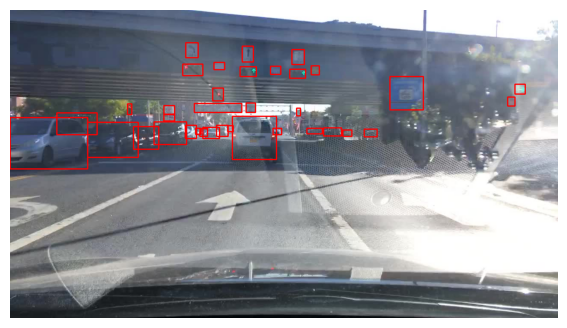

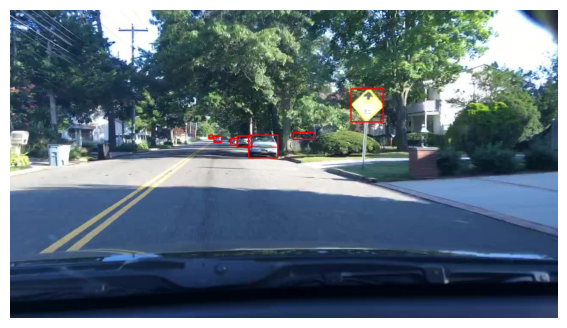

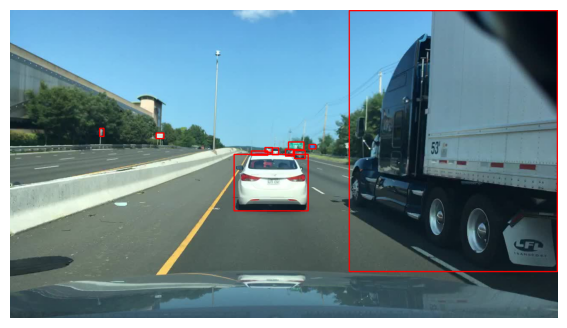

In [37]:
import random
from pathlib import Path
import cv2
import matplotlib.pyplot as plt

root = Path("/content/self-healing-detector/data/yolo/train_day")

imgs = list((root/"images").glob("*.jpg"))

for img_path in random.sample(imgs, 3):
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    label_path = root/"labels"/f"{img_path.stem}.txt"

    for line in label_path.read_text().splitlines():
        cls, x, y, bw, bh = map(float, line.split())
        x *= w; y *= h; bw *= w; bh *= h
        x1 = int(x-bw/2); y1 = int(y-bh/2)
        x2 = int(x+bw/2); y2 = int(y+bh/2)
        cv2.rectangle(img, (x1,y1), (x2,y2), (255,0,0), 2)

    plt.figure(figsize=(8,4))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

In [38]:
!rm -rf /content/self-healing-detector/data/raw/bdd100k_images_100k
!rm -rf /content/self-healing-detector/data/raw/bdd100k_images_10k
!rm -rf /content/self-healing-detector/data/raw/bdd100k_det_20_labels_trainval

!df -h

Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   54G   59G  48% /
tmpfs            64M     0   64M   0% /dev
shm             5.7G     0  5.7G   0% /dev/shm
/dev/root       2.0G  1.3G  696M  65% /usr/sbin/docker-init
tmpfs           6.4G  3.2M  6.4G   1% /var/colab
/dev/sda1       119G   87G   33G  73% /kaggle/input
tmpfs           6.4G     0  6.4G   0% /proc/acpi
tmpfs           6.4G     0  6.4G   0% /proc/scsi
tmpfs           6.4G     0  6.4G   0% /sys/firmware


In [39]:

%%writefile /content/self-healing-detector/src/model/unfused.py
#!/usr/bin/env python3
"""
Unfused YOLO11 loader for BatchNorm adaptation.

Implements §5 of the build spec:
- Never call .predict() or .fuse().
- Load YOLO11s in its unfused DetectionModel state.
- Re-enable BatchNorm running-stat updates.
- Snapshot and restore BN state exactly.
- Run inference through net(im) + non_max_suppression().
- Write verification results to results/logs/.
"""

import json
from pathlib import Path
from typing import Dict

import torch
from ultralytics import YOLO
from ultralytics.nn.modules import Conv
from ultralytics.utils.ops import non_max_suppression


BN_KEYS = ("running_mean", "running_var", "num_batches_tracked")


class UnfusedYOLO:

    def __init__(self, weights: str = "yolo11s.pt"):

        self.wrapper = YOLO(weights)

        # IMPORTANT: DetectionModel before any fusion
        self.net = self.wrapper.model

        self.net.eval()

        self.enable_bn_updates()

    def enable_bn_updates(self):

        for m in self.net.modules():

            if isinstance(m, torch.nn.BatchNorm2d):

                m.train()

                # cumulative moving average over adaptation window
                m.momentum = None

    def count_bn(self):

        return sum(
            isinstance(m, torch.nn.BatchNorm2d)
            for m in self.net.modules()
        )

    def count_conv(self):

        return sum(
            isinstance(m, Conv)
            for m in self.net.modules()
        )

    def snapshot_bn(self) -> Dict[str, torch.Tensor]:

        state = self.net.state_dict()

        return {
            k: v.clone()
            for k, v in state.items()
            if any(x in k for x in BN_KEYS)
        }

    def restore_bn(self, backup):

        state = self.net.state_dict()

        for k, v in backup.items():
            state[k] = v.clone()

        self.net.load_state_dict(state)

    @torch.no_grad()
    def forward_raw(self, image_tensor):

        return self.net(image_tensor)

    @torch.no_grad()
    def infer(
        self,
        image_tensor,
        conf=0.001,
        iou=0.6,
        nc=6,
        max_det=100,
    ):

        preds = self.forward_raw(image_tensor)

        dets = non_max_suppression(
            preds[0],
            conf_thres=conf,
            iou_thres=iou,
            nc=nc,
            agnostic=False,
            max_det=max_det,
        )

        return dets

    def verify(self):

        backup = self.snapshot_bn()

        dummy = torch.randn(1, 3, 768, 768)

        before = {
            k: v.clone()
            for k, v in backup.items()
        }

        self.forward_raw(dummy)

        after = self.snapshot_bn()

        changed = 0

        for k in before:

            if "num_batches_tracked" in k:
                if not torch.equal(before[k], after[k]):
                    changed += 1
            elif "running_mean" in k or "running_var" in k:
                if not torch.allclose(before[k], after[k]):
                    changed += 1

        self.restore_bn(before)

        restored = self.snapshot_bn()

        rollback_ok = True

        for k in before:
            if not torch.equal(before[k], restored[k]):
                rollback_ok = False
                break

        return {
            "bn_layers": self.count_bn(),
            "conv_modules": self.count_conv(),
            "bn_updated_after_forward": changed > 0,
            "bn_restore_ok": rollback_ok,
            "predict_called": False,
            "fuse_called": False,
        }


def save_verification(results, root):

    root = Path(root)

    out_dir = root / "results" / "logs"

    out_dir.mkdir(parents=True, exist_ok=True)

    with open(out_dir / "bn_verification.json", "w") as f:
        json.dump(results, f, indent=2)


if __name__ == "__main__":

    repo = "/content/self-healing-detector"

    model = UnfusedYOLO("yolo11s.pt")

    results = model.verify()

    save_verification(results, repo)

    print(json.dumps(results, indent=2))

Writing /content/self-healing-detector/src/model/unfused.py


In [41]:
from pathlib import Path

file = Path("/content/self-healing-detector/src/model/unfused.py")

text = file.read_text()

text = text.replace(
    "from ultralytics.utils.ops import non_max_suppression",
    "from ultralytics.utils.nms import non_max_suppression"
)

file.write_text(text)

print("✅ Patched ultralytics 8.3.x import.")

✅ Patched ultralytics 8.3.x import.


In [42]:
%cd /content/self-healing-detector

!python src/model/unfused.py

/content/self-healing-detector
{
  "bn_layers": 81,
  "conv_modules": 81,
  "bn_updated_after_forward": true,
  "bn_restore_ok": true,
  "predict_called": false,
  "fuse_called": false
}


In [43]:

%%writefile /content/self-healing-detector/configs/train_day.yaml
model: yolo11s.pt
data: /content/self-healing-detector/configs/bdd6_day.yaml

epochs: 35
imgsz: 768
batch: 12
workers: 2
cache: false
amp: true

optimizer: AdamW
lr0: 0.001
lrf: 0.01
warmup_epochs: 3
cos_lr: true
patience: 12

close_mosaic: 10

# --- shift-preserving augmentation ---
hsv_h: 0.015
hsv_s: 0.4
hsv_v: 0.15
degrees: 0.0
translate: 0.1
scale: 0.5
fliplr: 0.5
mosaic: 1.0
mixup: 0.0
copy_paste: 0.0
erasing: 0.0

project: /content/self-healing-detector/runs/detect
name: day_baseline

save_period: 5
seed: 0
deterministic: true

Writing /content/self-healing-detector/configs/train_day.yaml


In [50]:

%%writefile /content/self-healing-detector/scripts/02_train_baseline.py
#!/usr/bin/env python3

import argparse
import json
import random
import shutil
from pathlib import Path

import numpy as np
import torch
from ultralytics import YOLO


def seed_everything(seed=0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def make_checkpoint_callback(backup_dir):
    backup_dir.mkdir(parents=True, exist_ok=True)

    def on_fit_epoch_end(trainer):
        epoch = trainer.epoch + 1

        if epoch % 5 != 0:
            return

        weights = Path(trainer.save_dir) / "weights"

        best = weights / "best.pt"
        last = weights / "last.pt"

        if best.exists():
            shutil.copy2(best, backup_dir / f"best_epoch_{epoch:03d}.pt")

        if last.exists():
            shutil.copy2(last, backup_dir / f"last_epoch_{epoch:03d}.pt")

        manifest = {
            "epoch": epoch,
            "best_exists": best.exists(),
            "last_exists": last.exists(),
        }

        with open(backup_dir / f"epoch_{epoch:03d}.json", "w") as f:
            json.dump(manifest, f, indent=2)

        print(f"\n✅ Backup created at epoch {epoch}")

    return on_fit_epoch_end


def main():
    parser = argparse.ArgumentParser()

    parser.add_argument(
        "--config",
        default="/content/self-healing-detector/configs/train_day.yaml",
    )

    parser.add_argument(
        "--weights",
        default="yolo11s.pt",
    )

    parser.add_argument(
        "--root",
        default="/content/self-healing-detector",
    )

    parser.add_argument(
        "--resume",
        action="store_true",
    )

    args = parser.parse_args()

    seed_everything(0)

    root = Path(args.root)
    backup_dir = root / "results" / "checkpoints"

    model = YOLO(args.weights)

    model.add_callback(
        "on_fit_epoch_end",
        make_checkpoint_callback(backup_dir),
    )

    results = model.train(
        cfg=args.config,
        resume=args.resume,
    )

    save_dir = Path(results.save_dir)

    out_dir = root / "results" / "logs"
    out_dir.mkdir(parents=True, exist_ok=True)

    summary = {
        "save_dir": str(save_dir),
        "best": str(save_dir / "weights" / "best.pt"),
        "last": str(save_dir / "weights" / "last.pt"),
        "backup_dir": str(backup_dir),
        "epochs": 35,
        "imgsz": 768,
        "batch": 12,
        "workers": 2,
        "cache": False,
        "amp": True,
        "seed": 0,
    }

    with open(out_dir / "train_launch.json", "w") as f:
        json.dump(summary, f, indent=2)

    print(json.dumps(summary, indent=2))


if __name__ == "__main__":
    main()

Overwriting /content/self-healing-detector/scripts/02_train_baseline.py


In [51]:
!nvidia-smi
!df -h
!free -g

Sun Sep 20 15:00:55 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   67C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
%cd /content/self-healing-detector

!python scripts/02_train_baseline.py

/content/self-healing-detector
New https://pypi.org/project/ultralytics/8.4.157 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.253 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=12, bgr=0.0, box=7.5, cache=False, cfg=/content/self-healing-detector/configs/train_day.yaml, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/self-healing-detector/configs/bdd6_day.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=35, erasing=0.0, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.4, hsv_v=0.15, imgsz=768, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, 